# Kazan Reconstruction Review

Ноутбук для визуального разбора `observed vs reconstructed` по выборке `Казань + Выпечка сытная + 30 пекарен`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "processed"
REPORTS_DIR = ROOT / "reports"

RECON_PATH = DATA_DIR / "kazan_reconstructed_sku_day.csv"
PATH_SCORES_PATH = DATA_DIR / "kazan_decomposition_path_scores.csv"
ANCHOR_PATH = DATA_DIR / "kazan_anchor_suitability_map.csv"
SHARE_STABILITY_SUMMARY_PATH = DATA_DIR / "kazan_share_stability_summary.json"

RECON_PATH

WindowsPath('c:/Users/dns/Desktop/Projects/demand-forecasting-model/data/processed/kazan_reconstructed_sku_day.csv')

In [2]:
recon = pd.read_csv(RECON_PATH, encoding="utf-8-sig", low_memory=False)
path_scores = pd.read_csv(PATH_SCORES_PATH, encoding="utf-8-sig", low_memory=False)
anchor_map = pd.read_csv(ANCHOR_PATH, encoding="utf-8-sig", low_memory=False)

recon["date"] = pd.to_datetime(recon["date"], errors="coerce")
recon["observed_sales_qty"] = pd.to_numeric(recon["observed_sales_qty"], errors="coerce")
recon["reconstructed_sales_qty"] = pd.to_numeric(recon["reconstructed_sales_qty"], errors="coerce")
recon["reconstruction_abs_gap"] = pd.to_numeric(recon["reconstruction_abs_gap"], errors="coerce")
recon["reconstruction_bias"] = pd.to_numeric(recon["reconstruction_bias"], errors="coerce")

print(recon.shape)
recon.head(3)

(231695, 32)


,date,bakery_id,bakery_name,city,category_name,product_id,product_name,observed_sales_qty,release_qty,row_quality_score,...,mean_sku_share_in_bakery_sku_cluster,mean_bakery_share_in_city_sku,mean_bakery_share_in_bakery_cluster_sku,recon_bakery_total_to_category_to_sku_cluster_to_sku,recon_bakery_category_to_sku_cluster_to_sku,recon_city_sku_to_bakery,recon_bakery_cluster_sku_to_bakery,reconstructed_sales_qty,reconstruction_abs_gap,reconstruction_bias
0,2025-01-15,12,Восстания 117 Казань,Казань,Выпечка сытная,34,Беккен капуста,68.0,160.0,0.65,...,0.105707,0.052095,0.127147,83.784262,88.275177,66.369354,63.319044,88.275177,20.275177,20.275177
1,2025-01-16,12,Восстания 117 Казань,Казань,Выпечка сытная,34,Беккен капуста,77.0,126.0,0.65,...,0.105707,0.052095,0.127147,87.925944,89.297310,64.181353,68.913498,89.297310,12.297310,12.297310
2,2025-01-17,12,Восстания 117 Казань,Казань,Выпечка сытная,34,Беккен капуста,65.0,130.0,0.65,...,0.105707,0.052095,0.127147,85.482936,80.934399,69.078307,69.294938,80.934399,15.934399,15.934399


## 1. Общая сводка


In [3]:
summary = {
    "rows": len(recon),
    "dates": recon["date"].nunique(),
    "bakeries": recon["bakery_id"].nunique(),
    "sku": recon["product_id"].nunique(),
    "mean_observed": recon["observed_sales_qty"].mean(),
    "mean_reconstructed": recon["reconstructed_sales_qty"].mean(),
    "mean_abs_gap": recon["reconstruction_abs_gap"].mean(),
    "mean_bias": recon["reconstruction_bias"].mean(),
}
pd.Series(summary)

rows                  231695.000000
dates                    481.000000
bakeries                  30.000000
sku                       29.000000
mean_observed             38.170900
mean_reconstructed        38.109798
mean_abs_gap               7.192680
mean_bias                 -0.061102
dtype: float64

In [4]:
path_summary = (
    recon.groupby("best_decomposition_path", dropna=False)
    .agg(
        rows=("best_decomposition_path", "size"),
        mean_observed=("observed_sales_qty", "mean"),
        mean_reconstructed=("reconstructed_sales_qty", "mean"),
        mean_abs_gap=("reconstruction_abs_gap", "mean"),
        mean_bias=("reconstruction_bias", "mean"),
    )
    .sort_values("rows", ascending=False)
)
path_summary

,rows,mean_observed,mean_reconstructed,mean_abs_gap,mean_bias
best_decomposition_path,,,,,
bakery_category_to_sku_cluster_to_sku,149705,47.111171,47.110681,8.396431,-0.000490
bakery_total_to_category_to_sku_cluster_to_sku,53511,16.890757,16.589575,5.169505,-0.301181
city_sku_to_bakery,18356,34.302471,34.382218,6.216661,0.079748
bakery_cluster_sku_to_bakery,10072,25.551175,25.606302,1.845480,0.055127
NaN,51,7.450980,7.718746,3.806567,0.267766


## 2. Распределение ошибок


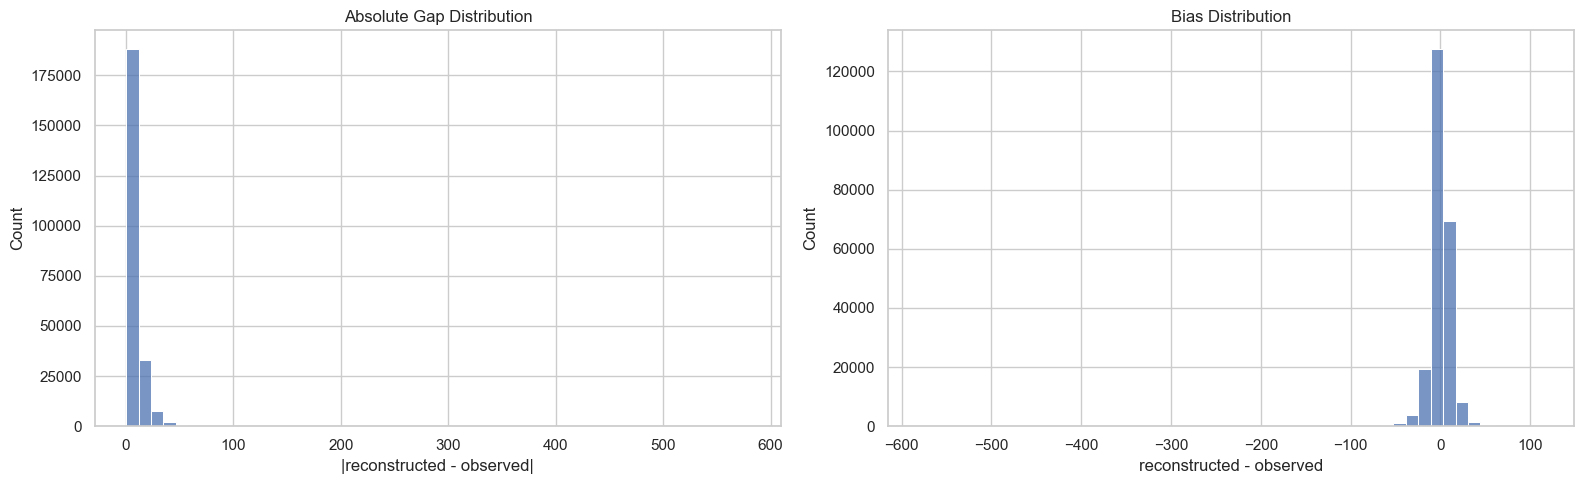

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(recon["reconstruction_abs_gap"].dropna(), bins=50, ax=axes[0])
axes[0].set_title("Absolute Gap Distribution")
axes[0].set_xlabel("|reconstructed - observed|")

sns.histplot(recon["reconstruction_bias"].dropna(), bins=50, ax=axes[1])
axes[1].set_title("Bias Distribution")
axes[1].set_xlabel("reconstructed - observed")
plt.tight_layout()

## 3. Выбор конкретной пары `bakery x sku`

Поменяйте `BAKERY_ID` и `PRODUCT_ID` на интересующую пару.


In [ ]:
pair_index = (
    recon.groupby([
        "bakery_id", "bakery_name", "product_id", "product_name", "best_decomposition_path"
    ], as_index=False)
    .agg(
        mean_observed=("observed_sales_qty", "mean"),
        mean_abs_gap=("reconstruction_abs_gap", "mean"),
        mean_bias=("reconstruction_bias", "mean"),
    )
    .sort_values(["mean_observed", "mean_abs_gap"], ascending=[False, True])
)
pair_index.head(20)

,bakery_id,bakery_name,product_id,product_name,best_decomposition_path,mean_observed,mean_abs_gap,mean_bias
509,142,Баки Урманче 6 Казань,1071,Треугольник курица безд,bakery_category_to_sku_cluster_to_sku,210.317597,21.221379,-1.251820
56,16,Кулагина 4 Казань,1071,Треугольник курица безд,bakery_category_to_sku_cluster_to_sku,200.185852,24.697129,1.932827
30,14,Ямашева 19А Казань,1071,Треугольник курица безд,city_sku_to_bakery,180.143451,21.105365,0.795943
107,21,Парковая 7 Казань,1071,Треугольник курица безд,bakery_category_to_sku_cluster_to_sku,172.688150,18.166496,0.455157
484,137,Татарстан 53А Казань,1071,Треугольник курица безд,city_sku_to_bakery,166.195426,24.304086,0.593252
392,89,Парина 6 Казань,10340,Кыстыбый П,bakery_category_to_sku_cluster_to_sku,165.226611,21.196296,-2.272606
408,102,Татарстан 16 Казань,1071,Треугольник курица безд,bakery_category_to_sku_cluster_to_sku,158.137214,16.356860,0.364532
459,107,Четаева 46А Казань,1071,Треугольник курица безд,bakery_category_to_sku_cluster_to_sku,150.257796,19.974489,0.794116
81,19,Хади Такташ 73 Казань,1071,Треугольник курица безд,bakery_category_to_sku_cluster_to_sku,144.920998,17.236151,-0.179558
5,12,Восстания 117 Казань,1071,Треугольник курица безд,bakery_category_to_sku_cluster_to_sku,142.692308,18.485584,1.472720


In [26]:
pair_index['bakery_id'].unique()

array([142,  16,  14,  21, 137,  89, 102, 107,  19,  12,  45,  50,  42,
        51, 156,  22,  87,  47,  81, 106,  66, 153, 155,  44, 158, 161,
       159, 151, 187, 168])

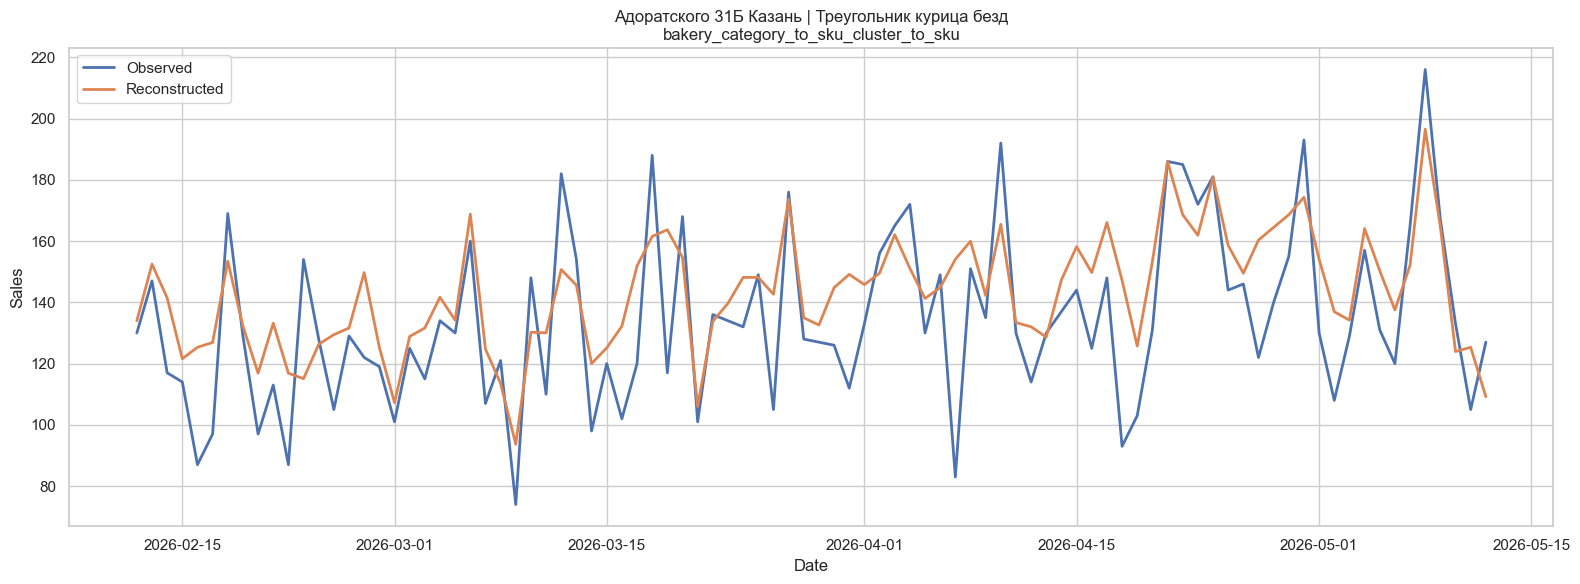

In [40]:
BAKERY_ID = 50
PRODUCT_ID = 1071

pair = recon[
    (recon["bakery_id"].astype(str) == str(BAKERY_ID))
    & (recon["product_id"].astype(str) == str(PRODUCT_ID))
].copy().sort_values("date")

pair[[
    "bakery_id", "bakery_name", "product_id", "product_name", "best_decomposition_path"
]].drop_duplicates()

pair_tail = pair.tail(90)

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(pair_tail["date"], pair_tail["observed_sales_qty"], label="Observed", linewidth=2)
ax.plot(pair_tail["date"], pair_tail["reconstructed_sales_qty"], label="Reconstructed", linewidth=2)
ax.set_title(
    f"{pair_tail['bakery_name'].iloc[0]} | {pair_tail['product_name'].iloc[0]}\n{pair_tail['best_decomposition_path'].iloc[0]}"
)
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()
plt.tight_layout()

In [13]:
pair[[
    "date",
    "observed_sales_qty",
    "reconstructed_sales_qty",
    "reconstruction_bias",
    "best_decomposition_path",
]].tail(20)

,date,observed_sales_qty,reconstructed_sales_qty,reconstruction_bias,best_decomposition_path
461,2026-04-23,84.0,75.544967,-8.455033,bakery_category_to_sku_cluster_to_sku
462,2026-04-24,65.0,80.191029,15.191029,bakery_category_to_sku_cluster_to_sku
463,2026-04-25,64.0,64.487340,0.487340,bakery_category_to_sku_cluster_to_sku
464,2026-04-26,57.0,58.447459,1.447459,bakery_category_to_sku_cluster_to_sku
465,2026-04-27,94.0,75.266203,-18.733797,bakery_category_to_sku_cluster_to_sku
466,2026-04-28,88.0,76.752943,-11.247057,bakery_category_to_sku_cluster_to_sku
467,2026-04-29,85.0,81.491926,-3.508074,bakery_category_to_sku_cluster_to_sku
468,2026-04-30,83.0,82.699902,-0.300098,bakery_category_to_sku_cluster_to_sku
469,2026-05-01,62.0,54.451846,-7.548154,bakery_category_to_sku_cluster_to_sku
470,2026-05-02,40.0,45.717249,5.717249,bakery_category_to_sku_cluster_to_sku


## 4. Сравнение decomposition-path на агрегированном уровне


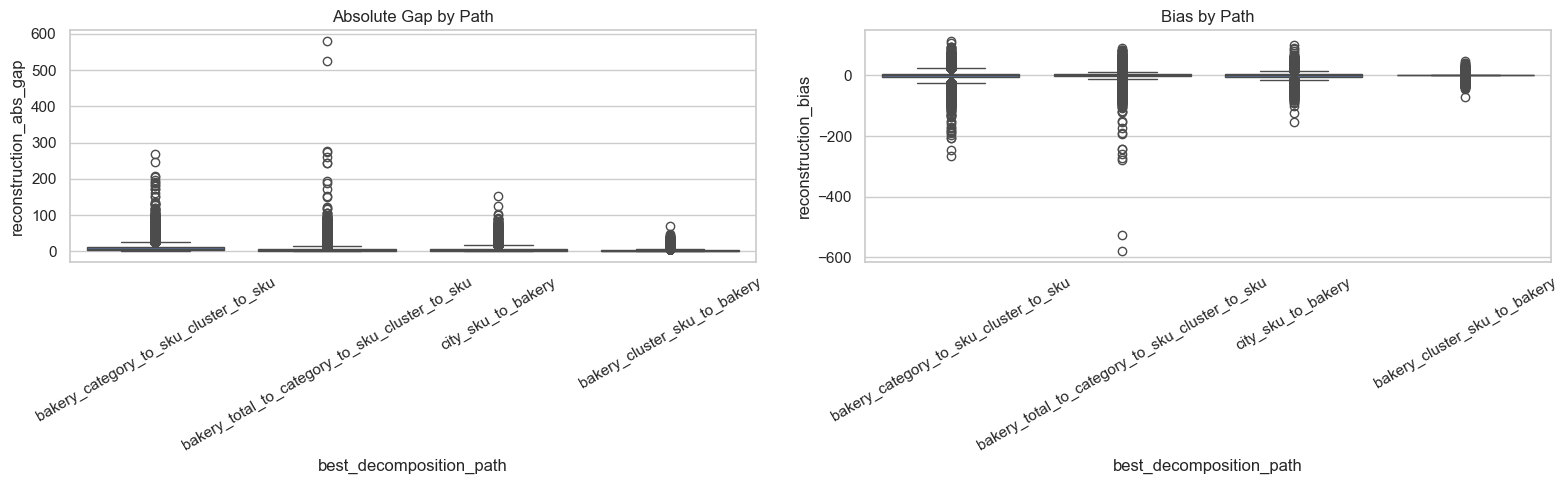

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(
    data=recon,
    x="best_decomposition_path",
    y="reconstruction_abs_gap",
    ax=axes[0],
)
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_title("Absolute Gap by Path")

sns.boxplot(
    data=recon,
    x="best_decomposition_path",
    y="reconstruction_bias",
    ax=axes[1],
)
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_title("Bias by Path")
plt.tight_layout()

## 5. Лучшие и худшие пары по среднему gap


In [15]:
pair_gap = (
    recon.groupby([
        "bakery_id", "bakery_name", "product_id", "product_name", "best_decomposition_path"
    ], as_index=False)
    .agg(
        mean_observed=("observed_sales_qty", "mean"),
        mean_abs_gap=("reconstruction_abs_gap", "mean"),
        mean_bias=("reconstruction_bias", "mean"),
    )
)
pair_gap["gap_ratio"] = pair_gap["mean_abs_gap"] / pair_gap["mean_observed"].replace(0, pd.NA)

print("Best pairs")
display(pair_gap.sort_values(["gap_ratio", "mean_observed"], ascending=[True, False]).head(20))

print("Worst pairs")
display(pair_gap.sort_values(["gap_ratio", "mean_observed"], ascending=[False, False]).head(20))

Best pairs


,bakery_id,bakery_name,product_id,product_name,best_decomposition_path,mean_observed,mean_abs_gap,mean_bias,gap_ratio
721,168,Калинина 32 Казань,10346,Сосиска под шубой,bakery_cluster_sku_to_bakery,59.488565,0.000000,0.000000,0.000000
711,168,Калинина 32 Казань,1071,Треугольник курица безд,bakery_cluster_sku_to_bakery,57.095634,0.000000,0.000000,0.000000
722,168,Калинина 32 Казань,10347,Жар пицца с курицей,bakery_cluster_sku_to_bakery,47.491060,0.000000,0.000000,0.000000
727,168,Калинина 32 Казань,10760,Пицца с колбасой,bakery_cluster_sku_to_bakery,47.250000,0.000000,0.000000,0.000000
709,168,Калинина 32 Казань,57,Сосиска в тесте,bakery_cluster_sku_to_bakery,37.908333,0.000000,0.000000,0.000000
712,168,Калинина 32 Казань,1076,Треугольник говядина безд,bakery_cluster_sku_to_bakery,28.831601,0.000000,0.000000,0.000000
723,168,Калинина 32 Казань,10556,Треугольник острый,bakery_cluster_sku_to_bakery,23.280922,0.000000,0.000000,0.000000
726,168,Калинина 32 Казань,10667,Элеш с курицей,bakery_cluster_sku_to_bakery,18.369748,0.000000,0.000000,0.000000
713,168,Калинина 32 Казань,1844,Киш курица,bakery_cluster_sku_to_bakery,18.117400,0.000000,0.000000,0.000000
720,168,Калинина 32 Казань,10340,Кыстыбый П,bakery_cluster_sku_to_bakery,16.332632,0.000000,0.000000,0.000000


Worst pairs


,bakery_id,bakery_name,product_id,product_name,best_decomposition_path,mean_observed,mean_abs_gap,mean_bias,gap_ratio
585,155,Тэцевская 4Д Казань,64,Беккен капуста пост,bakery_total_to_category_to_sku_cluster_to_sku,6.194444,14.803916,14.803916,2.389870
71,16,Кулагина 4 Казань,10658,я_не исп Пирожок,bakery_total_to_category_to_sku_cluster_to_sku,6.625000,10.849307,10.849307,1.637631
29,14,Ямашева 19А Казань,64,Беккен капуста пост,bakery_total_to_category_to_sku_cluster_to_sku,9.800000,9.304802,0.826534,0.949470
627,156,Олимпийская 5 Казань,10658,я_не исп Пирожок,bakery_total_to_category_to_sku_cluster_to_sku,4.923077,4.300102,4.064688,0.873458
372,87,Маршальская 25 Казань,10658,я_не исп Пирожок,bakery_total_to_category_to_sku_cluster_to_sku,6.692308,5.518097,1.230928,0.824543
95,19,Хади Такташ 73 Казань,10656,Пирожок картошка с сосиской,bakery_total_to_category_to_sku_cluster_to_sku,7.166667,5.234006,4.517873,0.730326
398,89,Парина 6 Казань,10658,я_не исп Пирожок,bakery_total_to_category_to_sku_cluster_to_sku,5.560000,3.898082,3.556838,0.701094
4,12,Восстания 117 Казань,64,Беккен капуста пост,bakery_total_to_category_to_sku_cluster_to_sku,3.900000,2.657391,0.671801,0.681382
739,187,2-я юго-западная 30 Казань,4241,ЖарЧизбургер,bakery_total_to_category_to_sku_cluster_to_sku,5.075269,3.455355,1.638248,0.680822
80,19,Хади Такташ 73 Казань,64,Беккен капуста пост,bakery_total_to_category_to_sku_cluster_to_sku,20.377358,13.137096,-10.263848,0.644691


## 6. Пересечение с anchor-level


In [16]:
anchor_cols = [
    "bakery_id",
    "bakery_name",
    "city",
    "category_name",
    "product_id",
    "product_name",
    "best_anchor_level",
    "best_anchor_score",
]
anchor_view = anchor_map[anchor_cols].drop_duplicates()

pair_with_anchor = pair_gap.merge(
    anchor_view,
    on=["bakery_id", "bakery_name", "product_id", "product_name"],
    how="left",
)

pair_with_anchor.groupby(["best_decomposition_path", "best_anchor_level"]).size().unstack(fill_value=0)

best_anchor_level,bakery_category,bakery_cluster,bakery_total,sku_cluster
best_decomposition_path,,,,
bakery_category_to_sku_cluster_to_sku,242,15,32,27
bakery_cluster_sku_to_bakery,10,1,11,2
bakery_total_to_category_to_sku_cluster_to_sku,170,32,59,106
city_sku_to_bakery,31,10,1,6


## 7. Быстрый helper для сохранения графика конкретной пары


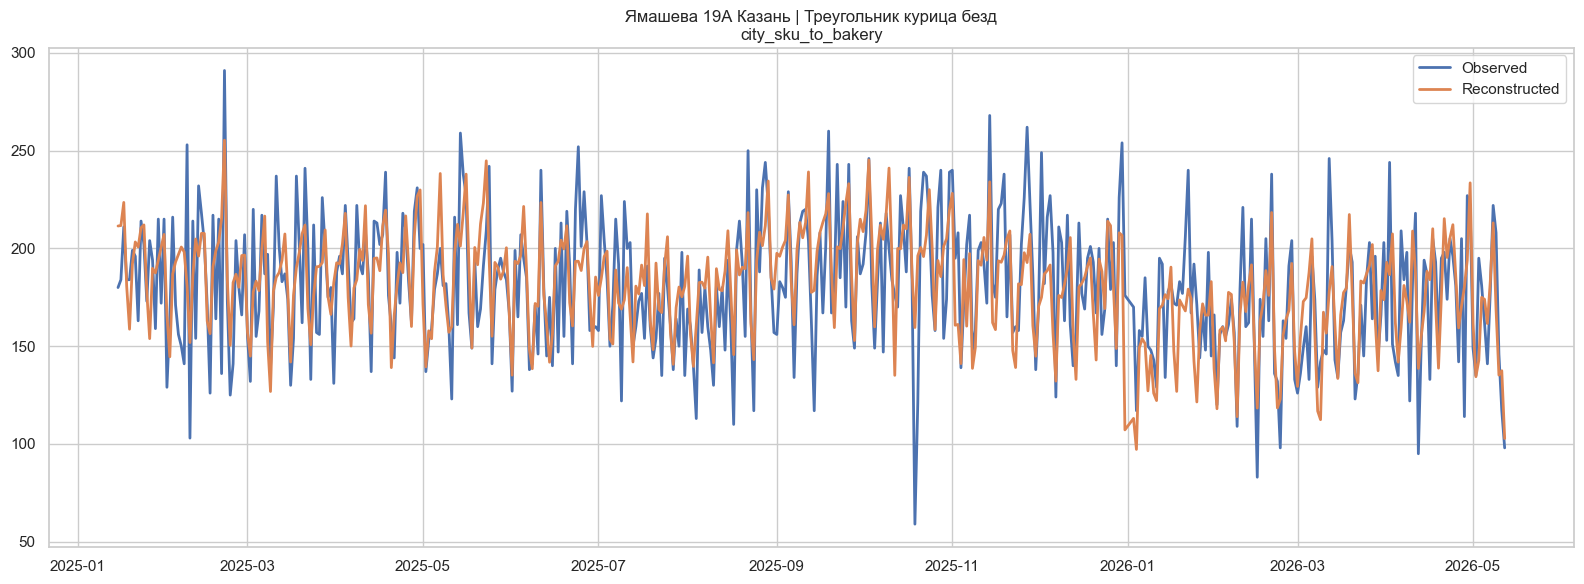

In [22]:
def plot_pair(bakery_id: str | int, product_id: str | int) -> pd.DataFrame:
    pair = recon[
        (recon["bakery_id"].astype(str) == str(bakery_id))
        & (recon["product_id"].astype(str) == str(product_id))
    ].copy().sort_values("date")
    if pair.empty:
        print("Pair not found")
        return pair

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(pair["date"], pair["observed_sales_qty"], label="Observed", linewidth=2)
    ax.plot(pair["date"], pair["reconstructed_sales_qty"], label="Reconstructed", linewidth=2)
    ax.set_title(
        f"{pair['bakery_name'].iloc[0]} | {pair['product_name'].iloc[0]}\n{pair['best_decomposition_path'].iloc[0]}"
    )
    ax.legend()
    plt.tight_layout()
    plt.show()
    return pair


plot_pair(14, 1071);